Columns: Index(['Month', 'State', 'Domestic Tourists', 'Foreign Tourists',
       'Revenue_Per_Tourist_INR', 'Seasonality_Index', 'Growth % (Approx.)',
       'Foreign_Revenue_Percent', 'Foreign Tourists.1', 'Total Tourists',
       'Foreign Tourist Share', 'Domestic Tourists_norm',
       'Foreign Tourists_norm', 'Revenue_Per_Tourist_INR_norm',
       'Growth % (Approx.)_norm', 'Seasonality_Index_norm', 'TPI'],
      dtype='object')

Using Features: Index(['Seasonality_Index', 'Revenue_Per_Tourist_INR',
       'Foreign_Revenue_Percent', 'Growth % (Approx.)'],
      dtype='object')

Model Coefficients:
                  Variable  Coefficient
0        Seasonality_Index     0.002319
1  Revenue_Per_Tourist_INR    -0.000232
2  Foreign_Revenue_Percent     0.001929
3       Growth % (Approx.)     0.005850

Test Performance:
RMSE: 0.07646590234364108
R²: 0.7868710051860082

Cross-Validation R² Scores: [0.79413413 0.6538443  0.79668191 0.79828338 0.72814662]
Average CV R²: 0.7542180672840109

T

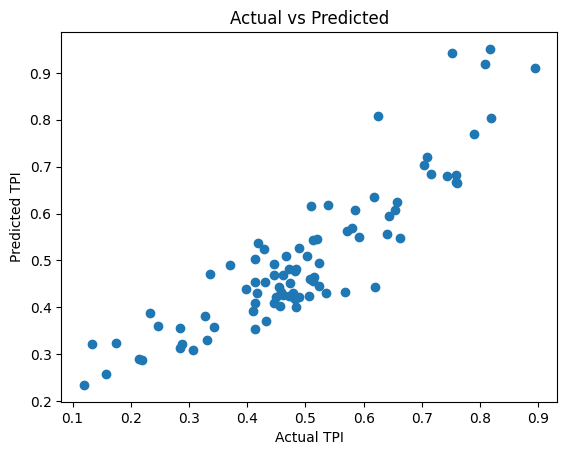

In [1]:
# ==============================
# STEP 1: IMPORT LIBRARIES
# ==============================
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import MinMaxScaler

import matplotlib.pyplot as plt

# ==============================
# STEP 2: LOAD DATA
# ==============================
df = pd.read_excel('/content/ABA Final Project.xlsx')

# Clean column names
df.columns = df.columns.str.strip()

# Drop missing values
df = df.dropna()

print("Columns:", df.columns)

# ==============================
# STEP 3: TARGET VARIABLE
# ==============================
y = df['TPI']

# ==============================
# STEP 4: FEATURE SELECTION (FIXED)
# ==============================
X = df[
    [
        'Seasonality_Index',
        'Revenue_Per_Tourist_INR',
        'Foreign_Revenue_Percent',
        'Growth % (Approx.)'   # ✅ corrected name
    ]
]

print("\nUsing Features:", X.columns)

# ==============================
# STEP 5: TRAIN-TEST SPLIT
# ==============================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ==============================
# STEP 6: TRAIN MODEL
# ==============================
model = LinearRegression()
model.fit(X_train, y_train)

# ==============================
# STEP 7: COEFFICIENTS
# ==============================
coefficients = pd.DataFrame({
    'Variable': X.columns,
    'Coefficient': model.coef_
})

print("\nModel Coefficients:")
print(coefficients)

# ==============================
# STEP 8: PREDICTIONS
# ==============================
y_pred = model.predict(X_test)

# ==============================
# STEP 9: MODEL PERFORMANCE
# ==============================
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("\nTest Performance:")
print("RMSE:", rmse)
print("R²:", r2)

# ==============================
# STEP 10: CROSS VALIDATION
# ==============================
cv_scores = cross_val_score(model, X, y, cv=5, scoring='r2')

print("\nCross-Validation R² Scores:", cv_scores)
print("Average CV R²:", cv_scores.mean())

# ==============================
# STEP 11: PREDICT ALL STATES
# ==============================
df['Predicted_Score'] = model.predict(X)

# ==============================
# STEP 12: NORMALIZE SCORE (0–100)
# ==============================
scaler = MinMaxScaler()
df['Normalized_Score'] = scaler.fit_transform(df[['Predicted_Score']]) * 100

# ==============================
# STEP 13: RANK STATES
# ==============================
df['Rank'] = df['Normalized_Score'].rank(ascending=False)

df_sorted = df.sort_values(by='Normalized_Score', ascending=False)

print("\nTop State Rankings:")
print(df_sorted[['State', 'Normalized_Score', 'Rank']])

# ==============================
# STEP 14: GAP ANALYSIS
# ==============================
df['Gap'] = df['TPI'] - df['Predicted_Score']

print("\nGap Analysis:")
print(df[['State', 'Gap']])

# ==============================
# STEP 15: VISUALIZATION
# ==============================
plt.scatter(y_test, y_pred)
plt.xlabel("Actual TPI")
plt.ylabel("Predicted TPI")
plt.title("Actual vs Predicted")
plt.show()

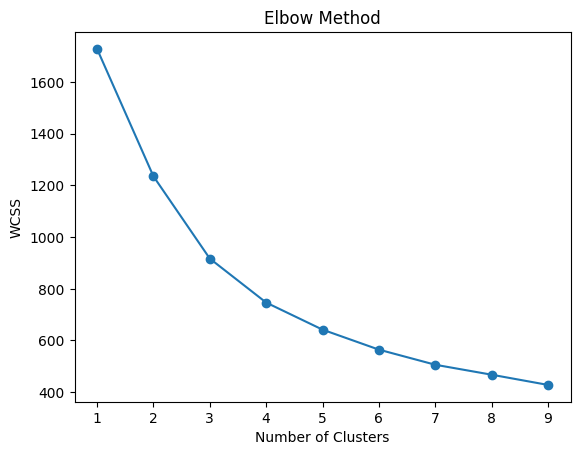


Cluster Distribution:
Cluster
2    190
0    161
1     81
Name: count, dtype: int64

Cluster-wise Mean Values:
         Seasonality_Index  Revenue_Per_Tourist_INR  Foreign_Revenue_Percent  \
Cluster                                                                        
0                67.132209               202.830596                11.420333   
1               -70.517480               159.519831                50.926060   
2               -26.822998               110.707286                12.751753   

         Growth % (Approx.)  
Cluster                      
0                  4.478137  
1                  4.762716  
2                  4.227158  


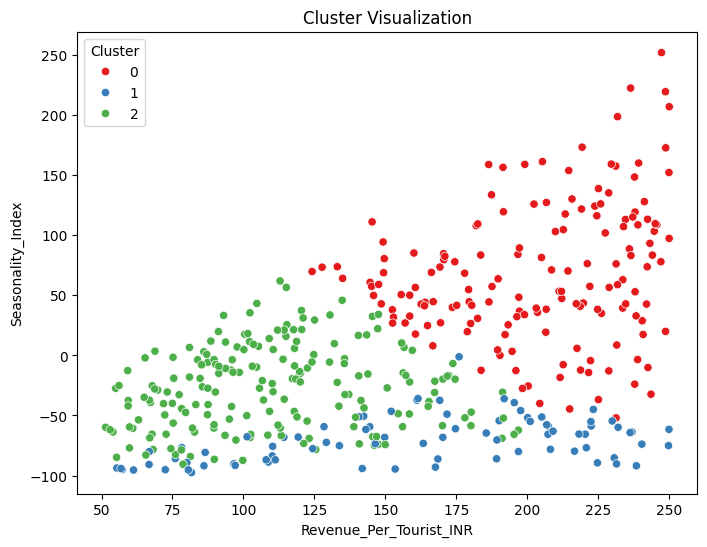

In [2]:
# ==============================
# STEP 1: IMPORT LIBRARIES
# ==============================
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns

# ==============================
# STEP 2: SELECT VARIABLES
# (Same as regression for consistency)
# ==============================
cluster_data = df[
    [
        'Seasonality_Index',
        'Revenue_Per_Tourist_INR',
        'Foreign_Revenue_Percent',
        'Growth % (Approx.)'
    ]
]

# ==============================
# STEP 3: SCALE DATA
# ==============================
scaler = StandardScaler()
scaled_data = scaler.fit_transform(cluster_data)

# ==============================
# STEP 4: ELBOW METHOD
# ==============================
wcss = []

for i in range(1, 10):
    kmeans = KMeans(n_clusters=i, random_state=42, n_init=10)
    kmeans.fit(scaled_data)
    wcss.append(kmeans.inertia_)

# Plot Elbow Curve
plt.plot(range(1, 10), wcss, marker='o')
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()

# ==============================
# STEP 5: APPLY K-MEANS
# (Choose optimal k from elbow, usually 3 or 4)
# ==============================
k = 3  # You can adjust based on elbow graph

kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(scaled_data)

# ==============================
# STEP 6: VIEW CLUSTERS
# ==============================
print("\nCluster Distribution:")
print(df['Cluster'].value_counts())

print("\nCluster-wise Mean Values:")
print(df.groupby('Cluster')[cluster_data.columns].mean())

# ==============================
# STEP 7: VISUALIZATION
# ==============================
plt.figure(figsize=(8,6))
sns.scatterplot(
    x=df['Revenue_Per_Tourist_INR'],
    y=df['Seasonality_Index'],
    hue=df['Cluster'],
    palette='Set1'
)

plt.title("Cluster Visualization")
plt.show()
